### The goal of this notebook is to test various simulation methods, as well as to cluster final conformations to compare methods.

In [1]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_functions as vis # our functions for visualization
import sim_methods as sim # our functions for simulation

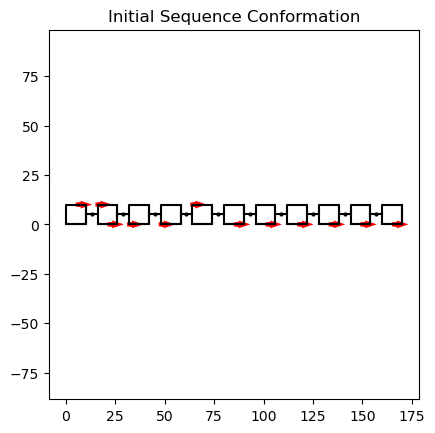

In [2]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

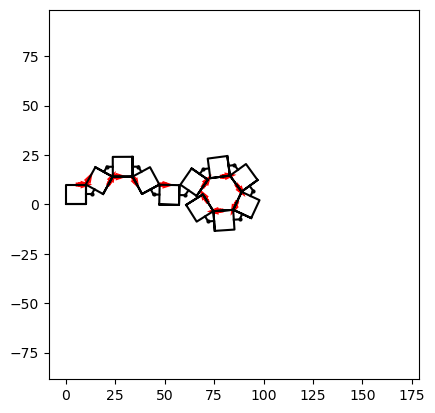

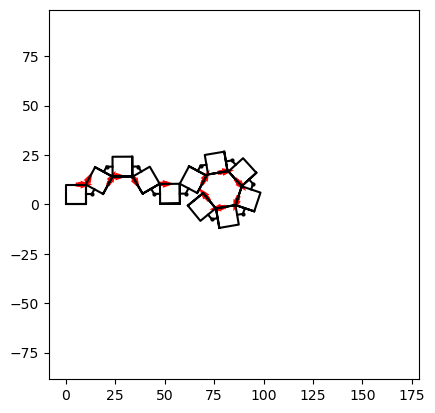

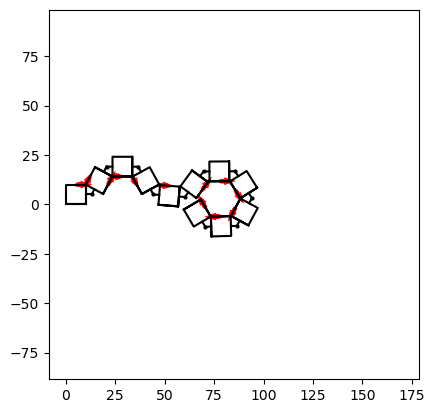

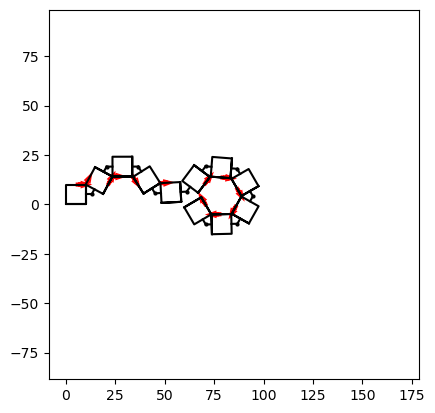

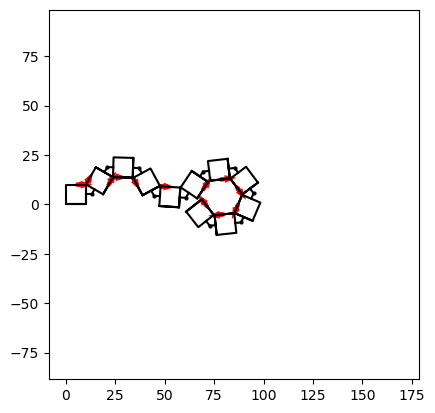

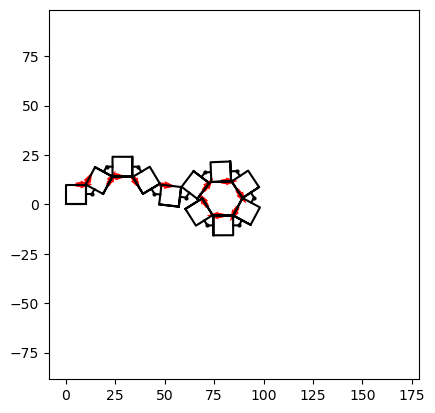

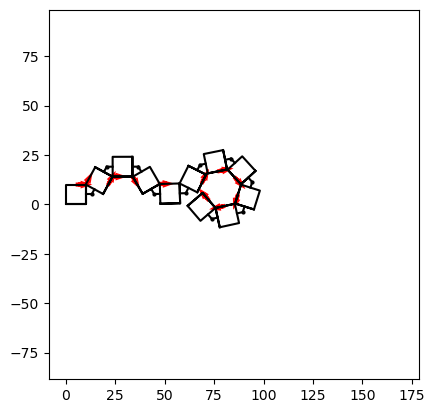

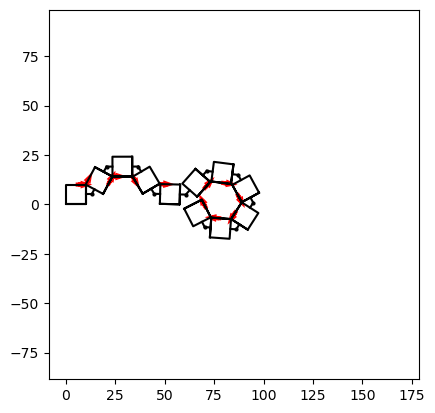

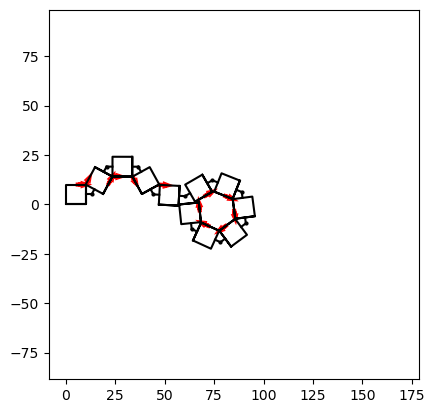

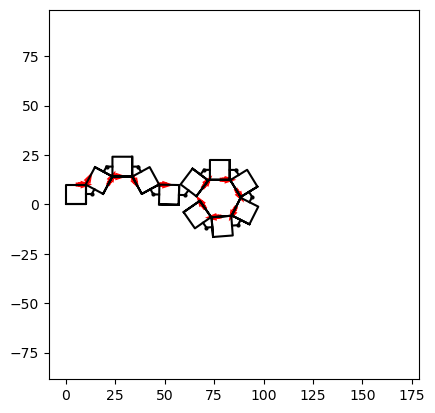

In [3]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 10 # number of simulations
final_hinges, final_es = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True)

In [4]:
print(final_hinges)

[[241.1256328  119.08842366 118.18223235 240.35449481 236.58326641
  132.17501602 118.44449095 119.1654929  118.65976566 118.38603752]
 [241.62679916 118.60148764 119.88584963 240.36741476 241.53000986
  127.53865028 122.71474176 119.1747996  118.32637833 119.57776402]
 [241.74256546 118.1205077  118.73944172 236.78243461 238.44105446
  126.62286815 121.58559439 119.56512154 119.95194251 118.86326716]
 [241.74650127 118.32571823 122.18103657 240.82953774 230.09015358
  122.30463732 124.48410761 120.62743795 120.71447789 119.14962834]
 [240.10641516 118.23025083 120.14682152 237.80570511 239.91804189
  130.29247038 120.34723805 120.10163651 119.16563498 121.95379526]
 [241.68521038 118.18254924 120.99250913 232.46116461 239.36379494
  129.62826857 121.11378577 118.34949841 118.30882203 122.06385188]
 [241.4100932  118.68844298 119.92230089 241.51893875 241.88917942
  128.05069337 120.9035036  120.12442051 119.85415265 118.25391724]
 [241.81499005 118.26854696 120.39354814 238.11902382 2